In [1]:
%matplotlib widget

import time, csv, threading
from collections import deque

import serial
import pandas as pd

import matplotlib.pyplot as plt
import ipywidgets as w
from IPython.display import display, clear_output

In [2]:
# ===== CONFIG =====
PORT = "COM10"      # <-- CAMBIA A TU COM
BAUD = 115200

N = 200             # ventana (>=100)
UI_HZ = 2           # >=2 Hz
UI_PERIOD = 1.0 / UI_HZ

CSV_PATH = "U1A5_Cisneros_Daniel_ESP32.csv"

# ===== BUFFERS =====
buf_t  = deque(maxlen=N)
buf_s1 = deque(maxlen=N)
buf_s2 = deque(maxlen=N)

# ===== ESTADO / RECURSOS =====
count = 0
running = False
last_sample = None

min_line  = {"s1": None, "s2": None}   # NEGRO
max_floor = {"s1": None, "s2": None}   # BLANCO
thr       = {"s1": None, "s2": None}

cap_black = deque(maxlen=2)
cap_white = deque(maxlen=2)

t0_pc = None

lock = threading.Lock()

# Recursos que se crean al iniciar monitor
ser = None
csv_file = None
wr = None
stop_reader = True
reader_thread = None
timer = None

# Figuras / líneas
raw_fig = raw_ax = raw_l1 = raw_l2 = None
norm_fig = norm_ax = norm_l1 = norm_l2 = None

# UI containers (se asignan en celda 3)
plots_out = None
status_out = None

def is_num(x):
    return x is not None and isinstance(x, (int, float))

def clamp01(x):
    if x < 0: return 0.0
    if x > 1: return 1.0
    return float(x)

def update_thr():
    for ch in ["s1","s2"]:
        mn, mx = min_line[ch], max_floor[ch]
        thr[ch] = (mn + mx)/2.0 if (is_num(mn) and is_num(mx) and mn != mx) else None

def compute_norm_and_line(ch, s):
    mn, mx = min_line[ch], max_floor[ch]
    if not (is_num(mn) and is_num(mx)) or mn == mx:
        return None, None
    mid = (mn + mx)/2.0

    # Caso normal
    if mx > mn:
        norm = clamp01((s - mn)/(mx - mn))
        line = (s <= mid)
    # Caso invertido
    else:
        norm = clamp01((mn - s)/(mn - mx))
        line = (s >= mid)

    return norm, line

def delta(last2):
    if len(last2) < 2:
        return None
    a, b = last2[-2], last2[-1]
    return {"s1": abs(b["s1"]-a["s1"]), "s2": abs(b["s2"]-a["s2"])}

def parse_line(line: str):
    line = (line or "").strip().replace("\r","")
    if not line or line.lower().startswith("t_ms"):
        return None
    p = line.split(",")
    if len(p) < 3:
        return None
    try:
        return int(p[0]), int(p[1]), int(p[2])
    except:
        return None

def cleanup():
    """Detiene timer/hilo, cierra serial/csv y cierra figuras. Seguro si se llama varias veces."""
    global stop_reader, timer, reader_thread, ser, csv_file, wr
    global raw_fig, norm_fig, raw_ax, norm_ax, raw_l1, raw_l2, norm_l1, norm_l2
    global running

    running = False
    stop_reader = True

    # parar timer
    try:
        if timer is not None:
            timer.stop()
    except:
        pass
    timer = None

    # cerrar serial/csv
    try:
        if csv_file is not None:
            csv_file.flush()
            csv_file.close()
    except:
        pass
    csv_file = None
    wr = None

    try:
        if ser is not None and ser.is_open:
            ser.close()
    except:
        pass
    ser = None

    # hilo (daemon) no bloquea, pero lo nullificamos
    reader_thread = None

    # cerrar figuras (en memoria)
    try:
        if raw_fig is not None:
            plt.close(raw_fig)
    except:
        pass
    try:
        if norm_fig is not None:
            plt.close(norm_fig)
    except:
        pass

    raw_fig = raw_ax = raw_l1 = raw_l2 = None
    norm_fig = norm_ax = norm_l1 = norm_l2 = None

def cleanup_io():
    """Detiene timer/hilo y cierra serial/csv, PERO conserva las figuras."""
    global stop_reader, timer, reader_thread, ser, csv_file, wr, running

    running = False
    stop_reader = True

    # parar timer
    try:
        if timer is not None:
            timer.stop()
    except:
        pass
    timer = None

    # cerrar CSV
    try:
        if csv_file is not None:
            csv_file.flush()
            csv_file.close()
    except:
        pass
    csv_file = None
    wr = None

    # cerrar Serial
    try:
        if ser is not None and ser.is_open:
            ser.close()
    except:
        pass
    ser = None

    reader_thread = None

In [3]:
# 1) Mata cualquier monitor previo + limpia la salida de ESTA celda
cleanup()
clear_output(wait=True)

# 2) UI (botones)
btn_run   = w.ToggleButton(value=False, description="Start/Stop", button_style="")
btn_black = w.Button(description="Capturar NEGRO (línea)", button_style="warning")
btn_white = w.Button(description="Capturar BLANCO (fondo)", button_style="info")
btn_reset = w.Button(description="Reset calibración", button_style="danger")
btn_close = w.Button(description="Cerrar (stop + guardar)", button_style="danger")

# 3) Contenedores: uno para texto, uno para plots (CLAVE anti-duplicados)
status_out = w.Output()
plots_out  = w.Output()

def set_status(text):
    with status_out:
        status_out.clear_output(wait=True)
        print(text)

def on_run(change):
    global running, t0_pc
    running = bool(change["new"])
    if running and t0_pc is None:
        t0_pc = time.time()

btn_run.observe(on_run, names="value")

def on_black(_):
    global last_sample
    with lock:
        if not last_sample:
            set_status("⚠️ No hay muestra aún. Inicia Start/Stop y espera a recibir datos.")
            return
        min_line["s1"] = last_sample["s1"]
        min_line["s2"] = last_sample["s2"]
        cap_black.append(last_sample.copy())
        update_thr()
    set_status("✅ Capturado NEGRO. Revisa thr y luego captura BLANCO.")

def on_white(_):
    global last_sample
    with lock:
        if not last_sample:
            set_status("⚠️ No hay muestra aún. Inicia Start/Stop y espera a recibir datos.")
            return
        max_floor["s1"] = last_sample["s1"]
        max_floor["s2"] = last_sample["s2"]
        cap_white.append(last_sample.copy())
        update_thr()
    set_status("✅ Capturado BLANCO. Ya debe funcionar NORM y LINEA/NO.")

def on_reset(_):
    with lock:
        min_line["s1"]=min_line["s2"]=None
        max_floor["s1"]=max_floor["s2"]=None
        thr["s1"]=thr["s2"]=None
        cap_black.clear()
        cap_white.clear()
    set_status("✅ Calibración reiniciada.")

def on_close(_):
    cleanup()
    set_status(f"✅ Cerrado.\nCSV: {CSV_PATH}\nMuestras registradas: {count}")

btn_black.on_click(on_black)
btn_white.on_click(on_white)
btn_reset.on_click(on_reset)
btn_close.on_click(on_close)

# 4) Render UI (solo una vez, en esta celda)
display(w.HBox([btn_run, btn_black, btn_white, btn_reset, btn_close]))
display(status_out)
display(plots_out)

set_status(
    "Listo ✅\n"
    "Siguiente: corre la CELDA 4 para arrancar el monitor.\n"
    "Luego activa Start/Stop y haz Capturar NEGRO / BLANCO.\n"
)

Output()

Output()

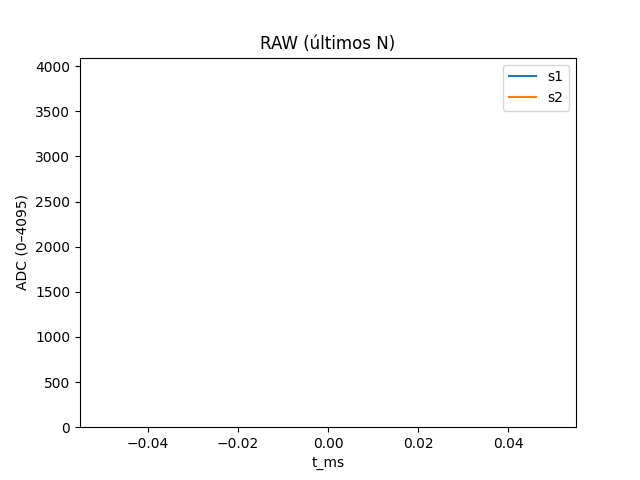

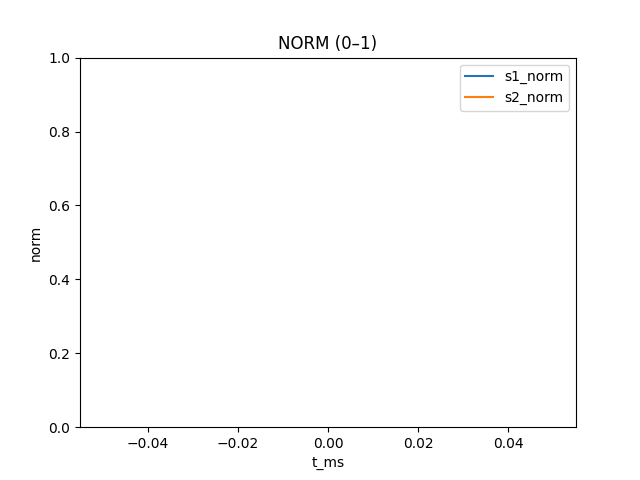

In [4]:
from IPython.display import clear_output
import matplotlib.pyplot as plt

global raw_fig, raw_ax, raw_l1, raw_l2
global norm_fig, norm_ax, norm_l1, norm_l2

with plots_out:
    plots_out.clear_output(wait=True)
    plt.close('all')

    raw_fig, raw_ax = plt.subplots()
    (raw_l1,) = raw_ax.plot([], [], label="s1")
    (raw_l2,) = raw_ax.plot([], [], label="s2")
    raw_ax.set_title("RAW (últimos N)")
    raw_ax.set_xlabel("t_ms")
    raw_ax.set_ylabel("ADC (0–4095)")
    raw_ax.set_ylim(0, 4095)
    raw_ax.legend()

    norm_fig, norm_ax = plt.subplots()
    (norm_l1,) = norm_ax.plot([], [], label="s1_norm")
    (norm_l2,) = norm_ax.plot([], [], label="s2_norm")
    norm_ax.set_title("NORM (0–1)")
    norm_ax.set_xlabel("t_ms")
    norm_ax.set_ylabel("norm")
    norm_ax.set_ylim(0, 1)
    norm_ax.legend()

    display(raw_fig)
    display(norm_fig)

set_status("✅ Figuras listas. Ahora corre CELDA 5.")

In [5]:
# Detén/cierra monitor previo (pero conserva figuras)
cleanup_io()

# Asegúrate de que existen figuras (celda 4)
if raw_fig is None or norm_fig is None:
    set_status("⚠️ Primero corre CELDA 4 (crear figuras).")
    raise RuntimeError("Faltan figuras: ejecuta celda 4.")

global count, last_sample, stop_reader, t0_pc, reader_thread, timer
global ser, csv_file, wr

# Abre Serial
ser = serial.Serial(PORT, BAUD, timeout=0.2)
time.sleep(0.3)
ser.reset_input_buffer()

# Abre CSV (sobrescribe)
csv_file = open(CSV_PATH, "w", newline="")
wr = csv.writer(csv_file)
wr.writerow(["t_ms","s1","s2","s1_norm","s2_norm","thr1","thr2","line1","line2"])
csv_file.flush()

# Reset buffers / estado
with lock:
    buf_t.clear(); buf_s1.clear(); buf_s2.clear()
    count = 0
    last_sample = None
    stop_reader = False
    t0_pc = None  # se setea al poner Start

def reader_fn():
    global count, last_sample
    while not stop_reader:
        line = ser.readline().decode(errors="ignore")
        parsed = parse_line(line)
        if parsed is None:
            continue
        t_ms, s1, s2 = parsed

        with lock:
            last_sample = {"t_ms": t_ms, "s1": s1, "s2": s2}

            if running:
                count += 1
                buf_t.append(t_ms); buf_s1.append(s1); buf_s2.append(s2)

                s1_norm, line1 = compute_norm_and_line("s1", s1)
                s2_norm, line2 = compute_norm_and_line("s2", s2)

                wr.writerow([
                    t_ms, s1, s2,
                    "" if s1_norm is None else round(s1_norm,4),
                    "" if s2_norm is None else round(s2_norm,4),
                    "" if thr["s1"] is None else round(thr["s1"],1),
                    "" if thr["s2"] is None else round(thr["s2"],1),
                    "" if line1 is None else int(line1),
                    "" if line2 is None else int(line2),
                ])

                if count % 50 == 0:
                    csv_file.flush()

reader_thread = threading.Thread(target=reader_fn, daemon=True)
reader_thread.start()

def ui_tick():
    with lock:
        # RAW
        if len(buf_t) >= 2:
            raw_l1.set_data(list(buf_t), list(buf_s1))
            raw_l2.set_data(list(buf_t), list(buf_s2))
            raw_ax.set_xlim(buf_t[0], buf_t[-1])

        # NORM si hay calibración
        if len(buf_t) >= 2 and (thr["s1"] is not None or thr["s2"] is not None):
            n1 = [compute_norm_and_line("s1", v)[0] for v in buf_s1]
            n2 = [compute_norm_and_line("s2", v)[0] for v in buf_s2]
            norm_l1.set_data(list(buf_t), n1)
            norm_l2.set_data(list(buf_t), n2)
            norm_ax.set_xlim(buf_t[0], buf_t[-1])

        raw_fig.canvas.draw_idle()
        norm_fig.canvas.draw_idle()

        hz = count / max(0.001, (time.time() - t0_pc)) if (running and t0_pc) else 0.0
        dB = delta(cap_black); dW = delta(cap_white)

        if last_sample:
            t_ms = last_sample["t_ms"]; s1 = last_sample["s1"]; s2 = last_sample["s2"]
            _, line1 = compute_norm_and_line("s1", s1)
            _, line2 = compute_norm_and_line("s2", s2)
        else:
            t_ms=s1=s2=line1=line2=None

    set_status(
        f"{'▶ RUN' if running else '⏸ STOP'} | Muestras log: {count} | Hz aprox: {hz:.1f}\n"
        f"Última: t_ms={t_ms} s1={s1} s2={s2}\n"
        f"min_line(NEGRO): {min_line}\n"
        f"max_floor(BLANCO): {max_floor}\n"
        f"thr: {thr}\n"
        f"Δ NEGRO: {dB} | Δ BLANCO: {dW}\n"
        f"LINEA/NO: s1={line1}  s2={line2}\n"
        f"CSV: {CSV_PATH}\n"
        "Tip: Captura NEGRO y BLANCO para activar NORM."
    )

timer = raw_fig.canvas.new_timer(interval=int(UI_PERIOD*1000))
timer.add_callback(ui_tick)
timer.start()

set_status("✅ Monitor activo. Activa Start/Stop para comenzar.")